# The Wheel — sell puts, then calls, forever for "income"? 🎡
### The retail options-income machine, in plain English

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_income%3F: Busted](https://img.shields.io/badge/Free_income%3F-Busted-8b949e?style=flat-square)

All over r/thetagang and a thousand "passive income" videos: the **Wheel**. *Sell a cash-secured **put** on SPY each month and pocket the premium. If the stock dips and you get "assigned," no problem — you now own the shares, so **sell calls** against them and keep pocketing premium. When they get called away, go back to selling puts. Round and round — "income" every month, up market or down.*

It sounds like rent on your money. Is it? We rebuild the Wheel on **33 years of real SPY**, pricing each month's option transparently from the **VIX**, and race it against just **holding SPY**. The short answer: it's not free income — it's **short volatility wearing an income costume**. It keeps a slice of the up months, gives the rest away, and still owns the crashes.

> 📓 **Plain-language layer.** Want the Black-Scholes premium, the paired *t*-stats and the capture decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is drawn by the code beside it. We price the option with a *transparent model* (Black-Scholes, VIX as the implied vol) — not a live option chain — and that model is *generous* to the seller, so reality is a bit worse. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from the_wheel import data, strategy as st

HAVE_REAL = data.have_real()
M = data.load_real().iloc[:-1] if HAVE_REAL else None   # drop the in-progress final month
print("real SPY+VIX cache present:", HAVE_REAL,
      "| months:", (0 if M is None else len(M)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-18', 'window': '1993-01-31 → 2026-05-31', 'n': 401, 'vix_mean': 19.6, 'vix_med': 17.9, 'prem_mo': 2.25, 'spy_lo': 24.11, 'spy_hi': 754.54, 'wheel_cagr': 11.61, 'wheel_vol': 8.7, 'wheel_sharpe': 1.32, 'wheel_mdd': -22.8, 'wheel_skew': -1.87, 'wheel_final': 39.23, 'spy_cagr': 8.09, 'spy_vol': 14.9, 'spy_sharpe': 0.6, 'spy_mdd': -55.8, 'spy_skew': -0.36, 'spy_final': 13.44, 'cash_cagr': 3.04, 'cash_final': 2.72, 'edge_full': 2.5, 't_full': 1.73, 'win': 58, 'edge_h1': 6.21, 't_h1': 3.11, 'edge_h2': -1.2, 't_h2': -0.58, 'up_cap': 69, 'dn_cap': 36, 'n_up': 253, 'n_dn': 147, 'spy_up': 3.24, 'wheel_up': 2.25, 'spy_dn': -3.55, 'wheel_dn': -1.28, 'worst1': -12.3, 'worst1_date': '2020-03', 'y2008': -10.7, 'worst5': -51, 'costs': [(0.0, 2.5, 1.73, 11.61), (0.1, 1.3, 0.9, 10.29), (0.25, -0.5, -0.35, 8.33), (0.5, -3.5, -2.43, 5.15)], 'syn': [(1.0, 0, -3.71, -7.9, 45, 46, -1.67), (1.0, 1, -3.37, -7.2, 45, 51, -3.0), (1.2, 1, 1.05, 2.3, 55, 42, -3.0)]}


real SPY+VIX cache present: True | months: 401


## The answer first

| Question | Answer |
|---|---|
| Is the monthly premium real money? | **Yes — but it's not free.** You're paid because you're **selling insurance** (short volatility). The cheque is the *variance risk premium*, not magic income. |
| Does the Wheel beat just holding SPY? | **Only sometimes, and not reliably.** Gross of costs it looks great (CAGR 11.6% vs 8.1%), but the edge **flipped negative** in the last 16 years and dies the moment you pay real trading costs. |
| Is it "market-neutral income"? | **No.** It keeps only **~69%** of the up months but rides **most of the way down** in crashes. That's a *directional* bet with the upside chopped off. |
| So what *is* the Wheel? | **A covered-call / short-put position in disguise** — short volatility. Skew **-1.9** (vs SPY's -0.36): tiny steady gains, rare ugly losses. |

> The premium is real; it's the price of selling insurance. The "income" is the upside you handed over. One crash collects on the policy.

## 1 · The claim

> *"Sell a cash-secured **put** at-the-money on SPY. If it expires above your strike, you keep the premium — free money. If it drops below, you're **assigned** the shares at a price you liked anyway. Now you own SPY, so **sell covered calls** at-the-money and keep collecting. When the calls get exercised, you're back in cash — start the wheel again. Premium every single month, in any market."*

It's seductive because **every leg collects cash up front**. Selling the put pays you. Selling the call pays you. The wheel never stops turning, so the income never stops… right?

## 2 · So what?

If true, the Wheel would be a holy grail: equity-like returns with bond-like calm and a steady monthly cheque. That's the dream every "theta gang" post is selling. But there's a catch hiding in plain sight. **When you sell that put, what are you giving up?** If SPY rips upward, your put expires worthless — you keep a tiny premium and **miss the whole rally** (you were in cash). And when you sell the call on shares you own, if SPY rips up you're **capped** — the gains above your strike aren't yours. Either way you've **sold away the upside**. The only question is whether the premium you bank is bigger than the upside you surrendered. Let's measure both.

## 3 · How would we even know?

We rebuild the Wheel on **401 months** of real SPY (1993-01-31 → 2026-05-31). Each month:

1. **Price the option honestly.** We use **Black-Scholes** with the **VIX** as the implied vol — a transparent, public model (no insider option chain). It's actually a *little generous* to the seller, because VIX usually sits **above** the volatility that actually shows up.
2. **Spin the wheel.** Sell the ATM put; if SPY ends below, get assigned and switch to selling ATM calls; when called away, switch back. Track the monthly return.
3. **Race it.** Against **buy-and-hold SPY** and a **cash** baseline. And split the months into *up* months and *down* months to see exactly how much of each the Wheel keeps.

**What would make us call it "income"?** A real, robust return edge over buy-and-hold that survives costs and doesn't depend on the decade. Spoiler: it doesn't.

## 4 · The teardown — let's actually look

**First, the headline race.** $1 in the Wheel vs $1 in buy-and-hold SPY vs $1 in cash, over 33 years — with the option premium priced from the VIX.

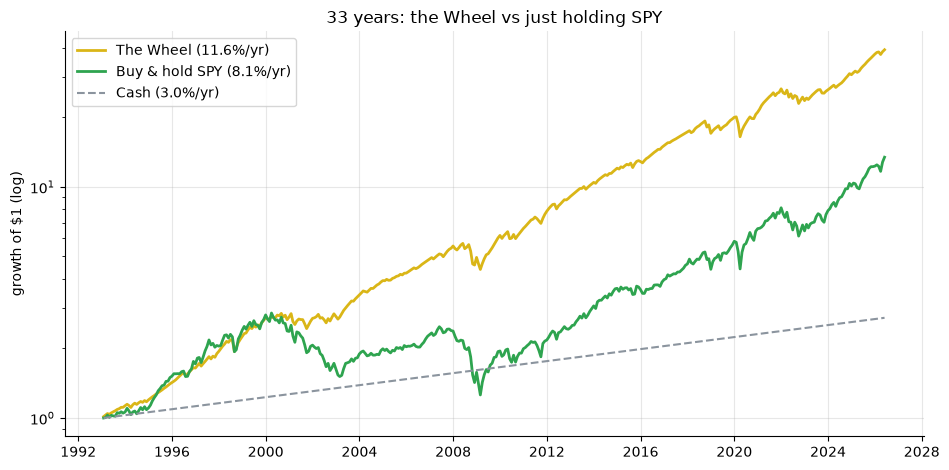

Wheel $39.2x   SPY $13.4x   (gross of trading costs)


In [2]:
if HAVE_REAL:
    w = st.run_wheel(M); spy = M['spy_ret'].to_numpy()
    nav_w = st.equity_curve(w['wheel_ret']); nav_s = st.equity_curve(spy)
    idx = M.index
    sw = st.summary(w['wheel_ret']); ss = st.summary(spy)
    cagr_w, cagr_s = sw['cagr']*100, ss['cagr']*100
else:
    idx = np.arange(R['n'])
    nav_w = (1+R['wheel_cagr']/100)**(np.arange(R['n'])/12)
    nav_s = (1+R['spy_cagr']/100)**(np.arange(R['n'])/12)
    cagr_w, cagr_s = R['wheel_cagr'], R['spy_cagr']
nav_c = (1+R['cash_cagr']/100)**(np.arange(len(nav_w))/12)
fig, ax = plt.subplots(figsize=(9.6, 4.8))
ax.plot(idx, nav_w, c=AMBER, lw=2, label=f'The Wheel ({cagr_w:.1f}%/yr)')
ax.plot(idx, nav_s, c=GREEN, lw=2, label=f'Buy & hold SPY ({cagr_s:.1f}%/yr)')
ax.plot(idx, nav_c, c=GREY, lw=1.5, ls='--', label=f"Cash ({R['cash_cagr']:.1f}%/yr)")
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.set_title('33 years: the Wheel vs just holding SPY')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Wheel ${nav_w[-1]:.1f}x   SPY ${nav_s[-1]:.1f}x   (gross of trading costs)')

Gross of costs the Wheel actually *wins* here — **11.6%/yr** vs SPY's **8.1%**, at a much smoother ride (a -23% worst drop vs SPY's brutal -56%). So is the pitch right after all? **No — and here's the tell.** That edge is entirely the *insurance premium* (VIX ran rich of reality for 33 years), and it comes with a nasty shape. Watch what happens in up months vs down months.

**The shape: what the Wheel keeps.** Split every month into *SPY went up* and *SPY went down*, and compare the Wheel's average to SPY's average in each bucket.

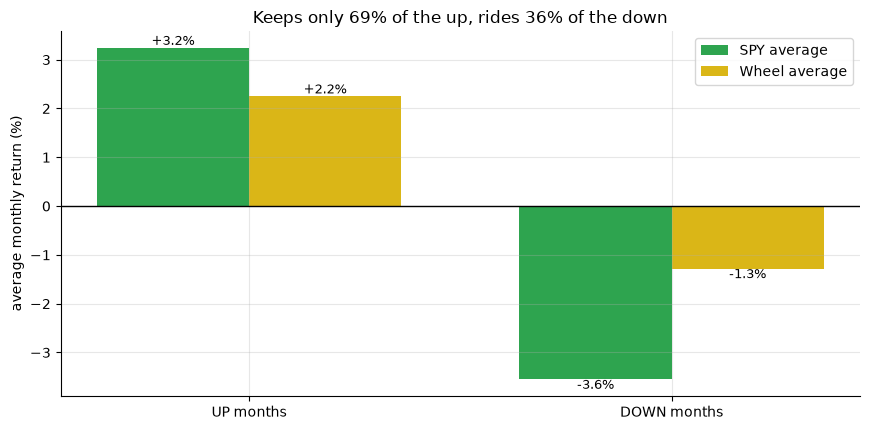

up-capture 69%   down-capture 36%


In [3]:
if HAVE_REAL:
    cap = st.capture(M, w)
    su, wu, sd, wd = cap['spy_up_mean']*100, cap['wheel_up_mean']*100, cap['spy_dn_mean']*100, cap['wheel_dn_mean']*100
    upc, dnc = cap['up_capture']*100, cap['dn_capture']*100
else:
    su, wu, sd, wd = R['spy_up'], R['wheel_up'], R['spy_dn'], R['wheel_dn']
    upc, dnc = R['up_cap'], R['dn_cap']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
x = np.arange(2)
ax.bar(x-0.18, [su, sd], 0.36, color=GREEN, label='SPY average')
ax.bar(x+0.18, [wu, wd], 0.36, color=AMBER, label='Wheel average')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(['UP months','DOWN months'])
ax.set_ylabel('average monthly return (%)')
ax.set_title(f'Keeps only {upc:.0f}% of the up, rides {dnc:.0f}% of the down'); ax.legend()
for xi,v in zip([x[0]-0.18,x[0]+0.18,x[1]-0.18,x[1]+0.18],[su,wu,sd,wd]):
    ax.annotate(f'{v:+.1f}%',(xi,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
plt.tight_layout(); plt.show()
print(f'up-capture {upc:.0f}%   down-capture {dnc:.0f}%')

There's the costume coming off. In **up** months the Wheel banks only **~69%** of SPY's gain — the rest is the upside you sold. In **down** months it still loses **~36%** of the way down. The rich VIX premium softens the falls *here*, but the right tail is chopped clean off. That asymmetry — **truncated upside, near-full downside** — is the exact fingerprint of being **short volatility**. It feels like income because the cheques are steady; it behaves like a covered call because the big up moves never reach you.

## 5 · The verdict

- **Signal — Mixed.** The "income beats the index" edge is **not reliable**: it was strongly positive in 1993–2009 (+6.2%/yr) but went **negative** in 2009–2026 (-1.2%/yr). Full-sample it doesn't clear the bar (*t* = 1.73). And the premium is just the insurance you're selling, not free money.
- **Tradability — Fragile.** Lovely on paper (Sharpe 1.32 vs 0.60) but the edge **vanishes at ~25¢ per $100 of trading cost**, and the payoff has skew **-1.9** — its worst 5 months sum to **-51%**. One crash hurts.
- **Free / market-neutral income? — Busted.** It keeps **69%** of up months and **36%** of down months — a directional long bet with the top sliced off, not income, and not neutral.

## 6 · Could you actually trade it? — pay the real costs

Every spin of the wheel means **buying back / writing options** and sometimes trading the shares — and options have real bid/ask spreads. Watch the edge over buy-and-hold as we charge a realistic cost per option written.

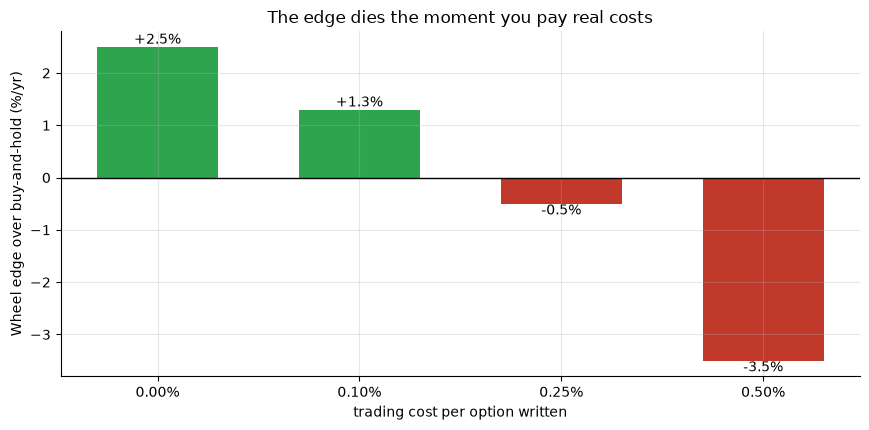

edge over B&H by cost: ['+2.5%', '+1.3%', '-0.5%', '-3.5%']


In [4]:
costs = R['costs']
cs = [c[0] for c in costs]
if HAVE_REAL:
    edges = [st.paired_t(st.run_wheel(M, cost_frac=c/100)['wheel_ret'], spy)['ann_drag']*100 for c in cs]
else:
    edges = [c[1] for c in costs]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
colors = [GREEN if e>0 else RED for e in edges]
ax.bar([f'{c:.2f}%' for c in cs], edges, color=colors, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('trading cost per option written')
ax.set_ylabel('Wheel edge over buy-and-hold (%/yr)')
ax.set_title('The edge dies the moment you pay real costs')
for i,e in enumerate(edges): ax.annotate(f'{e:+.1f}%',(i,e),ha='center',va='bottom' if e>=0 else 'top')
plt.tight_layout(); plt.show()
print('edge over B&H by cost:', [f'{e:+.1f}%' for e in edges])

At **zero** cost the Wheel beats buy-and-hold by ~2.5%/yr — but at a realistic **~25¢ per \$100** the edge is already **gone**, and at 50¢ it's a clear loser. And remember: even that gross edge was the VIX-is-rich premium, in a model with **no early assignment, no slippage, no pin risk** — all of which make a real Wheel worse. The honest version isn't "set the wheel and collect rent" — it's "you're selling insurance, sized small, and one bad year can take a chunk of your house."

## 7 · Going further 🎡

- **The same shape elsewhere.** [Study 62 — Premium-Seller](../../62-premium-seller/) shows a real covered-call *fund* (QYLD) trailing its own index; [Study 63 — Free-Fall](../../63-free-fall/) is the naive short-vol that blew up −95% in *Volmageddon*. The Wheel is the retail cousin of both.
- **Try a fair price.** In the quant notebook, when we price the option at the market's *actual* realised volatility instead of the rich VIX, the Wheel **loses** to buy-and-hold — proof the only edge was the insurance premium, not the wheel.
- **Add real frictions.** American-style early assignment, bid/ask, and choosing *out-of-the-money* strikes (what most wheelers actually do) all change the picture — and mostly for the worse. Fork the engine and try them.

*Think the Wheel is free income? Price the option yourself from the VIX, race it against just holding SPY, and check whether the "income" wasn't the upside you quietly sold.*